In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyshtools as pysh
from sklearn.decomposition import PCA
import os 
from meshplot import plot, subplot 
import anndata as ad
import pandas as pd

import igl
from scipy.sparse.linalg import eigsh
from tqdm import tqdm

In [2]:
import utils 
import spharm

In [3]:
timepoints = ['day1p5', 'day2', 'day2p5', 'day3', 'day3p5', 'day4', 'day4p5', 'day4p5-more']

zarr_names = {
    'day1p5': 'r0.zarr',
    'day2':'r0.zarr',
    'day2p5':'r0.zarr',
    'day3':'r0.zarr',
    'day3p5':'r0.zarr',
    'day4':'r0.zarr',
    'day4p5':'r0.zarr',
    'day4p5-more':'r0.zarr',
}


wells = {
    'day1p5': ['A01', 'A02', 'A03', 'A04', 'A06'],
    'day2': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day3': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'B02', 'B03'],
    'day3p5': ['A01', 'A02', 'A03', 'A04', 'B03'],
    'day4': ['A02', 'A03', 'A04', 'A05', 'A06', 'B01', 'B02'],
    'day4p5': ['A06', 'B06'],
    'day4p5-more': ['C01', 'C02', 'C03', 'C04', 'C06'],
}

rounds = {
    'day1p5': ['0_fused'],
    'day2': ['0_fused'],
    'day2p5': ['0_fused'],
    'day3': ['0_fused'],
    'day3p5': ['0_fused'],
    'day4': ['0_fused'],
    'day4p5': ['0_fused'],
    'day4p5-more': ['0_fused'],
}

meshes = {
    'day1p5': ['nnorg_linked'],
    'day2': ['nnorg_linked'],
    'day2p5': ['nnorg_linked'],
    'day3': ['nnorg_linked'],
    'day3p5': ['nnorg_linked'],
    'day4': ['nnorg_linked'],
    'day4p5': ['nnorgb3'],
    'day4p5-more': ['nnorgb3'],
}

tables = {
    'day1p5':['mesh_features', 'nnorg_linked_expanded1_features'],
    'day2':['mesh_features', 'nnorg_linked_expanded1_features'],
    'day2p5':['mesh_features', 'nnorg_linked_expanded1_features'],
    'day3':['mesh_features', 'nnorg_linked_expanded1_features'],
    'day3p5':['mesh_features', 'nnorg_linked_expanded1_features'],
    'day4':['mesh_features', 'nnorg_linked_expanded1_features'],
    'day4p5':['mesh_features', 'nnorgb3_expanded_features'],
    'day4p5-more':['mesh_features', 'nnorgb3_expanded_features'],
}

times_dic = {
    '1p5': 1.5,
    '2': 2,
    '2p5': 2.5,
    '3': 3,
    '3p5': 3.5,
    '4': 4,
    '4p5': 4.5,
    '4p5-more': 4.5
}

In [13]:
def rerun_spharm(save_path): 
    m = spharm.SpHarm()
    m.load_results(save_path)  
    m.align_with_pca() 
    m.compute_initial_parameterization()
    m.optimize(max_outer_iterations=100, primal_steps=100, verbose=False)
    m.compute_sh_coefficients(lmax=15)
    m.save_results(save_path)

def compute_hks(V, F, ts=[0.1, 1, 10, 100], k=100):
    """Simplified version for a single time scale"""
    L = igl.cotmatrix(V, F)
    M = igl.massmatrix(V, F, igl.MASSMATRIX_TYPE_VORONOI)
    
    eigvals, eigvecs = eigsh(L, k=k, M=M, which='LM', sigma=0)

    hks = [] 
    for t in ts:
        hks.append(np.einsum('i, ji->j', np.exp(eigvals*t), eigvecs**2))
    
    return np.array(hks)

def load_and_compute(save_path, ts=[0.1, 1, 10, 100]): 
    m = spharm.SpHarm()
    m.load_results(save_path)

    hks = compute_hks(m.v, m.f, ts=ts, k=100)

    theta, phi = m.coors[:, 0], m.coors[:, 1]
    lat, lon = utils.sph2latlon(theta, phi)

    spectrums = []
    for i in range(len(ts)):
        x = hks[i]
        # Compute SH coefficients
        sh = pysh.SHCoeffs.from_least_squares(x, lat, lon, 15)
        spectrum = sh.spectrum()
        spectrums.append(spectrum) 
    return np.array(spectrums)

def plot_explained_variance(pca):

    # Plot explained variance
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Plot explained variance ratio
    ax1.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
    ax1.set_xlabel('Principal Component')
    ax1.set_ylabel('Explained Variance Ratio')
    ax1.set_title('Explained Variance Ratio by Component')
    ax1.grid(True, alpha=0.3)

    # Plot cumulative explained variance
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    ax2.plot(range(0, len(cumulative_variance) + 1), np.concatenate(([0], cumulative_variance,)), 'ko-')
    ax2.set_xlabel('Number of Components')
    ax2.set_ylabel('Cumulative Explained Variance Ratio')
    ax2.set_title('Cumulative Explained Variance')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='95% variance')
    ax2.axhline(y=0.90, color='orange', linestyle='--', alpha=0.7, label='90% variance')
    ax2.set_ylim([0, 1])
    ax2.set_xlim([0, 10])
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # Print some statistics
    print(f"Total explained variance with {len(pca.explained_variance_ratio_)} components: {cumulative_variance[-1]:.4f}")
    print(f"Variance explained by first component: {pca.explained_variance_ratio_[0]:.4f}")
    print(f"Variance explained by second component: {pca.explained_variance_ratio_[1]:.4f}")

In [22]:
spectrums = [] 
clms = [] 
times = [] 
label_uids = []

for timepoint in timepoints:
    zarr_name = zarr_names[timepoint]
    for well_name in wells[timepoint]:
        round_name = rounds[timepoint][0]
        path = f"Data/fractal_output/{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/"
        labels = np.load(path + 'good_labels.npy').astype('int')
        mesh_name = meshes[timepoint][0]
        mesh_table_name = tables[timepoint][0] 
        print(well_name) 
        for label in tqdm(labels):
            save_path = f"Data/fractal_output/{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/meshes/{mesh_name}/{label}"

            mesh_table_path = f"Data/fractal_output/{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/tables/{mesh_table_name}"

            if os.path.exists(save_path + '_clms.npy'):
                if not os.path.exists(save_path + '_hks_spectrum.npy'):
                    coor_spectrum = load_and_compute(save_path)
                    np.save(save_path + '_hks_spectrum.npy', coor_spectrum)
                else: 
                    coor_spectrum = np.load(save_path + '_hks_spectrum.npy')
                    
                if np.max(coor_spectrum) > 1 or np.isnan(coor_spectrum).any():
                    print(save_path, np.max(coor_spectrum))
                else: 
                    spectrums.append(coor_spectrum)
                    times.append(timepoint[3:])



A01


100%|██████████| 117/117 [00:00<00:00, 1303.59it/s]


A02


100%|██████████| 56/56 [00:00<00:00, 1667.24it/s]


A03


...

100%|██████████| 107/107 [00:00<00:00, 1513.07it/s]


Data/fractal_output/day4p5-more/r0.zarr/C/04/0_fused/meshes/nnorgb3/131 nan
C06


  0%|          | 0/150 [00:00<?, ?it/s]

Data/fractal_output/day4p5-more/r0.zarr/C/06/0_fused/meshes/nnorgb3/11 nan


100%|██████████| 150/150 [00:00<00:00, 1757.35it/s]


In [23]:
times_number = [times_dic[time] for time in times]
times_number = np.array(times_number)

(3197, 4, 16)


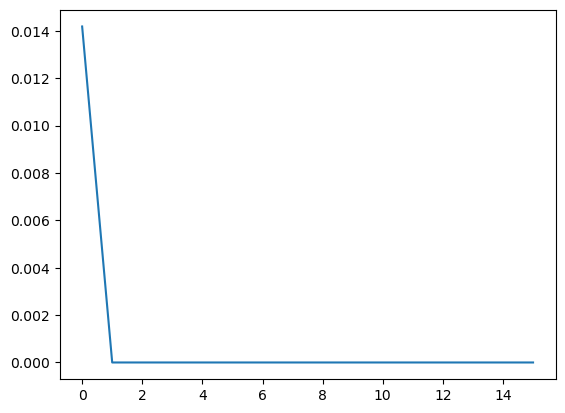

In [24]:
spectrums = np.array(spectrums)
print(spectrums.shape) 
medians = np.median(spectrums, axis=(0, 1))
plt.plot(medians) 
plt.show() 


In [25]:
spectrum_reshaped = spectrums.reshape(spectrums.shape[0], -1)
pca = PCA(n_components=10)
res = pca.fit(spectrum_reshaped) 

spectrum_pcs = pca.transform(spectrum_reshaped)
print(pca.components_.shape) 

(10, 64)


In [19]:
# Create the DataFrame
df_pca = pd.DataFrame({
    'label_uid': label_uids,
    'pca_coefficients': list(spectrum_pcs)
})
df_pca.to_csv('Data/pca_results.csv', index=False)

ValueError: All arrays must be of the same length

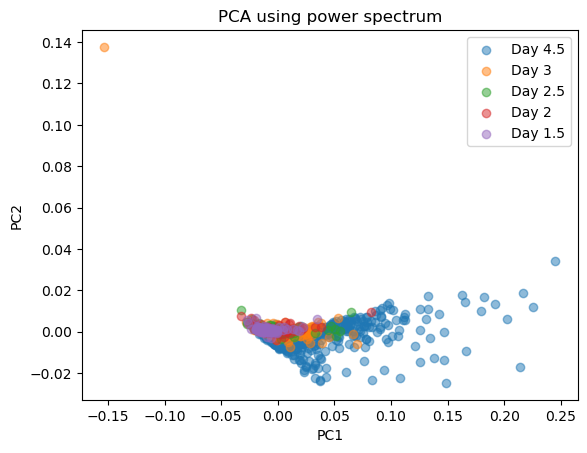

In [26]:

times_number = np.array(times_number)

for t in [4.5, 3, 2.5, 2, 1.5]: 
    times_mask = (times_number == t)

    plt.scatter(spectrum_pcs[:, 0][times_mask], spectrum_pcs[:, 1][times_mask], alpha=0.5, label=f'Day {t}')
plt.legend() 
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA using power spectrum')
plt.show()

[1.5 2.  2.5 3.  3.5 4.  4.5]


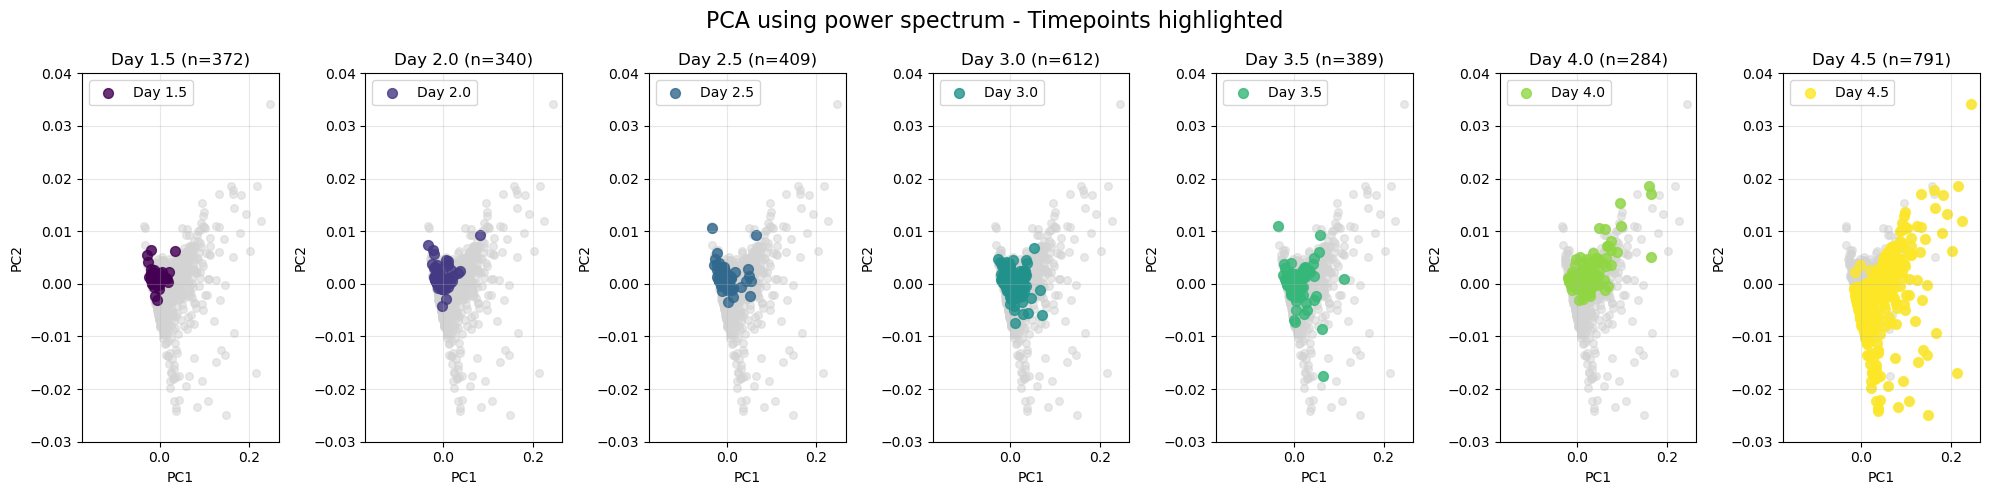

In [31]:
# Create subplots for each timepoint - spectrum PCA
unique_times = np.unique(times_number)

print(unique_times)
# Use a continuous colormap that represents time progression
cmap = plt.cm.viridis  # You can also try 'plasma', 'inferno', 'magma', 'cool', 'warm'
colors = [cmap(i / (len(unique_times) - 1)) for i in range(len(unique_times))]

fig, axes = plt.subplots(1, 7, figsize=(20, 5))

for i, time in enumerate(unique_times):
    ax = axes[i]
    
    # Plot all points in light gray
    ax.scatter(spectrum_pcs[:, 0], spectrum_pcs[:, 1], 
              c='lightgray', alpha=0.5, s=30)
    
    # Highlight current timepoint with color from continuous map
    times_mask = (times_number == time)
    ax.scatter(spectrum_pcs[:, 0][times_mask], spectrum_pcs[:, 1][times_mask], 
              c=[colors[i]], alpha=0.8, s=50, label=f'Day {time}')
    
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_ylim([-0.03, 0.04])
    ax.set_title(f'Day {time} (n={np.sum(times_mask)})')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle('PCA using power spectrum - Timepoints highlighted', fontsize=16)
plt.tight_layout()
plt.show()

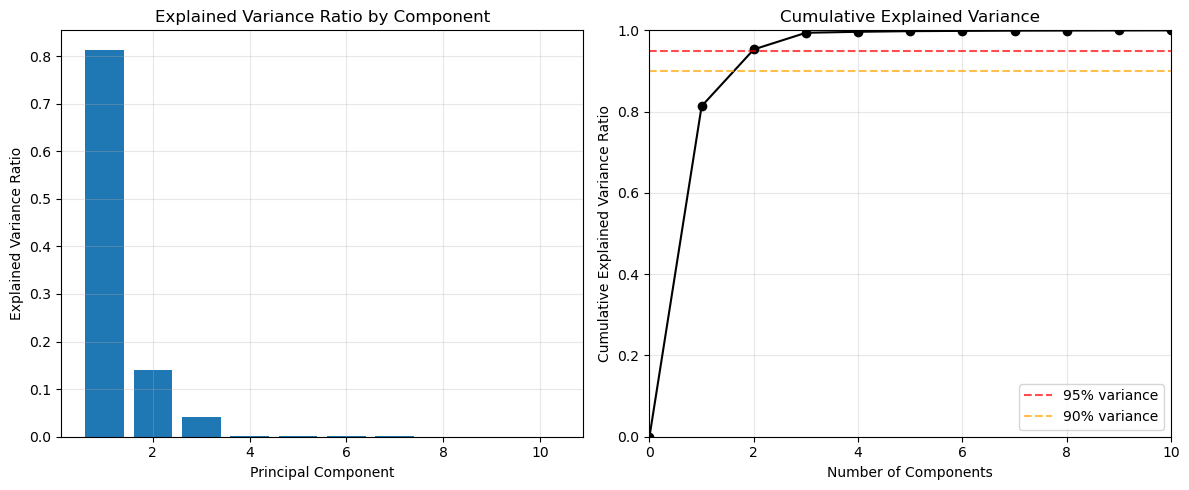

Total explained variance with 10 components: 0.9998
Variance explained by first component: 0.8134
Variance explained by second component: 0.1397


In [13]:
plot_explained_variance(pca)

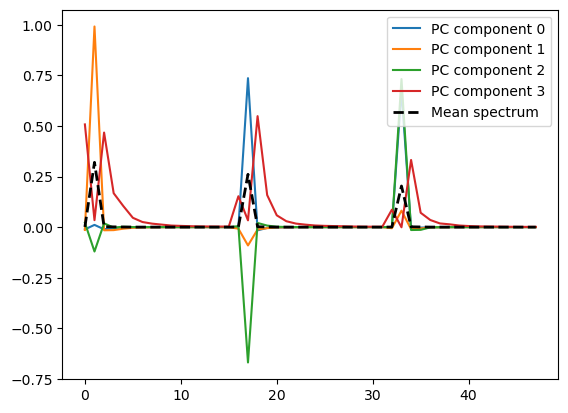

In [14]:
for (i, pc) in enumerate(pca.components_[:4]): 
    plt.plot(pc, '-', label=f'PC component {i}')
plt.plot(pca.mean_, 'k--', label='Mean spectrum', linewidth=2)
plt.legend(loc='upper right') 
plt.show() 

In [35]:
clms_reshaped = np.array(clms).reshape(len(clms), -1)
print(clms_reshaped.shape) 

clms = np.array(clms) 

(2259, 1536)


In [36]:
pca = PCA(n_components=10)
res = pca.fit(clms_reshaped) 

clm_pcs = pca.transform(clms_reshaped)
print(pca.components_.shape) 

(10, 1536)


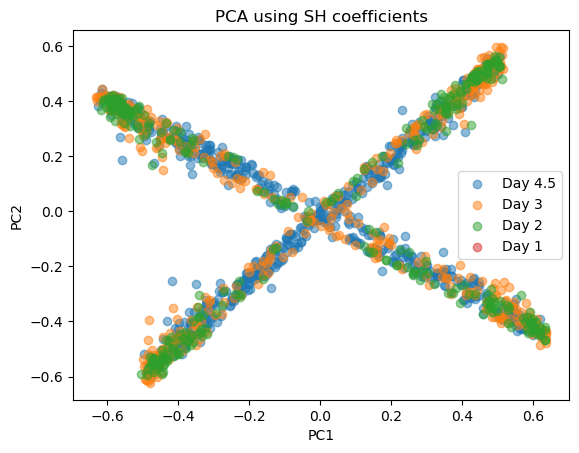

In [37]:

for t in [4.5, 3, 2, 1]: 
    times_mask = (times_number == t)

    plt.scatter(clm_pcs[:, 0][times_mask], clm_pcs[:, 1][times_mask], alpha=0.5, label=f'Day {t}')
plt.legend() 
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA using SH coefficients')
plt.show()

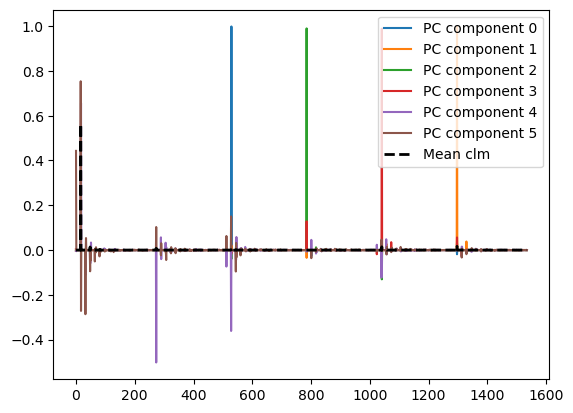

In [19]:
for (i, pc) in enumerate(pca.components_[:6]): 
    plt.plot(pc, '-', label=f'PC component {i}')
plt.plot(pca.mean_, 'k--', label='Mean clm', linewidth=2)
plt.legend(loc='upper right') 
plt.show() 

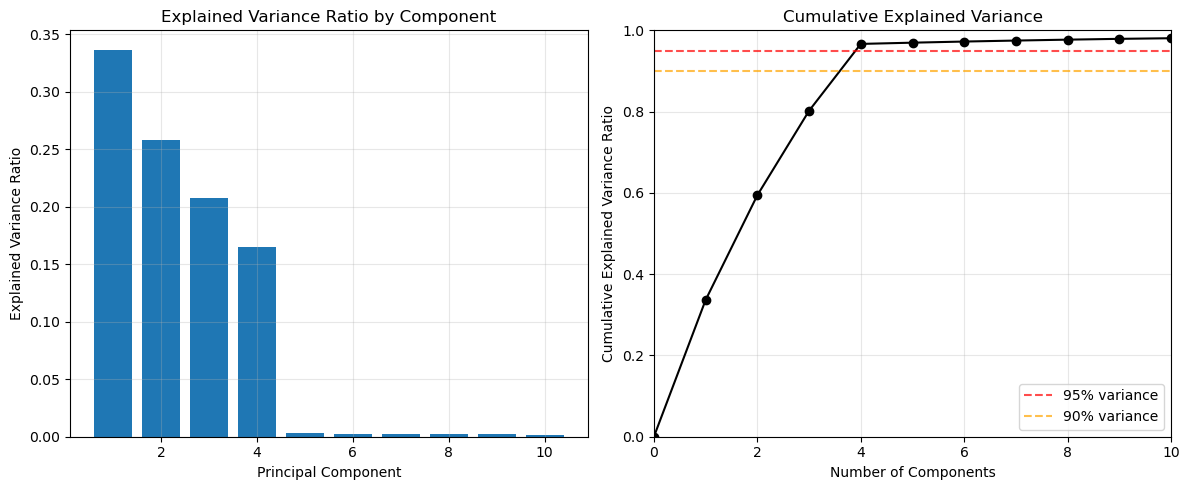

Total explained variance with 10 components: 0.9806
Variance explained by first component: 0.3365
Variance explained by second component: 0.2577


In [38]:
plot_explained_variance(pca)

Max value: 0.5618436877318683
Max index: 16
(2, 16, 16)
(2, 16, 16)
(2, 16, 16)


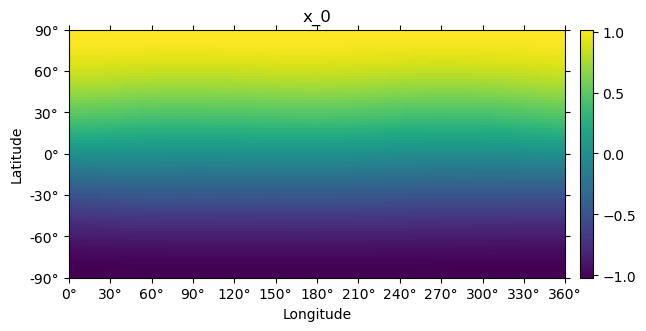

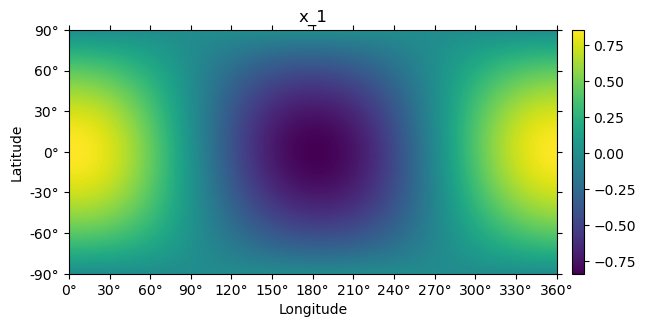

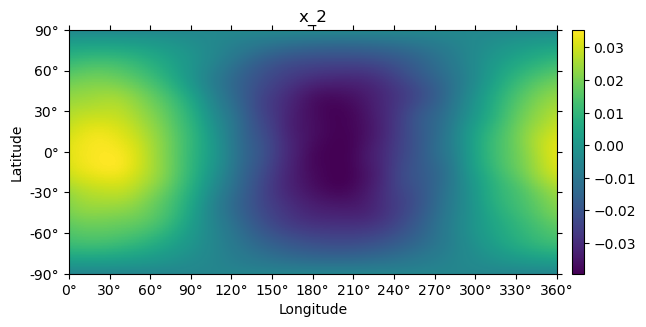

In [22]:
# for (i, pc) in enumerate(pca.components_[:1]):
pc = pca.mean_ + 0.5 * pca.components_[0]
max_value = np.max(pc)
max_index = np.argmax(pc)
print(f"Max value: {max_value}")
print(f"Max index: {max_index}")

reconstructed_clms = pc.reshape((3, 2, 16, 16))

coors = []
for (i, s) in enumerate(reconstructed_clms): 
    print(s.shape) 
    sh = pysh.SHCoeffs.from_array(s)
    grid = sh.expand(lmax=40)
    coors.append(grid.to_array())

    fig, ax = grid.plot(show=False, colorbar='right')
    ax.set_title(f'x_{i}')

In [23]:
utils.draw_3d_surface(coors[0], coors[1], coors[2], coors[2])